**Online Payments Fraud Detection System using Machine Learning**  by Sushant Kumar

In [1]:
pip install Flask

In [2]:
import os

os.environ['KAGGLE_USERNAME'] = 'KGAT_aa78b2ccf80edd59b2590d3922101bca#'
os.environ['KAGGLE_KEY'] = "KGAT_aa78b2ccf80edd59b2590d3922101bca"

In [3]:
pip install kaggle

In [4]:
!kaggle datasets download -d rupakroy/online-payments-fraud-detection-dataset

Dataset URL: https://www.kaggle.com/datasets/rupakroy/online-payments-fraud-detection-dataset
License(s): CC-BY-NC-SA-4.0
 68% 120M/178M [00:00<00:00, 1.25GB/s]
100% 178M/178M [00:00<00:00, 1.09GB/s]


In [5]:
!unzip online-payments-fraud-detection-dataset.zip

Archive:  online-payments-fraud-detection-dataset.zip
  inflating: PS_20174392719_1491204439457_log.csv  


In [6]:
#Importing the requisite Libraries
import pandas as pd
import numpy as np
from scipy import stats

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Pre-processing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

#Model Operations
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

import xgboost as xgb
from xgboost import XGBClassifier

#Pickle
import pickle

#Warnings
import warnings
warnings.filterwarnings('ignore')

In [7]:
#READING THE DATASET
df_orig=pd.read_csv('PS_20174392719_1491204439457_log.csv')
df_orig

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [8]:
#DESCRIPTIVE ANALYSIS
#VISUALIZING & ANALYZING DATA
df_orig.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [9]:
#MAKING A WORKING COPY OF THE ORIGINAL DATASET
df=df_orig.copy()
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [10]:
#DATA PRE-PROCESSING

#Removing unnecessary columns
df.drop(['isFlaggedFraud', 'nameOrig', 'nameDest'], axis=1, inplace=True)
df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0
1,1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0
2,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,1
3,1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1
4,1,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0
...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,1
6362616,743,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,1
6362617,743,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,1
6362618,743,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,1


In [11]:
#Replacing the 0s & 1s in 'isFraud' column with 'Legit Transaction' & 'Fraud Transaction' for better visuals
df.loc[df['isFraud']==0, 'isFraud']='Legit Transaction'
df.loc[df['isFraud']==1, 'isFraud']='Fraud Transaction'
df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,Legit Transaction
1,1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,Legit Transaction
2,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,Fraud Transaction
3,1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,Fraud Transaction
4,1,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,Legit Transaction
...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,Fraud Transaction
6362616,743,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,Fraud Transaction
6362617,743,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,Fraud Transaction
6362618,743,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,Fraud Transaction


In [12]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 8 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            6362620 non-null  int64  
 1   type            6362620 non-null  object 
 2   amount          6362620 non-null  float64
 3   oldbalanceOrg   6362620 non-null  float64
 4   newbalanceOrig  6362620 non-null  float64
 5   oldbalanceDest  6362620 non-null  float64
 6   newbalanceDest  6362620 non-null  float64
 7   isFraud         6362620 non-null  object 
dtypes: float64(5), int64(1), object(2)
memory usage: 388.3+ MB


In [13]:
#Ensuring there are no null values
df.isnull().sum()

,0
step,0
type,0
amount,0
oldbalanceOrg,0
newbalanceOrig,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


Text(0.5, 1.0, 'Transaction Count by Type')

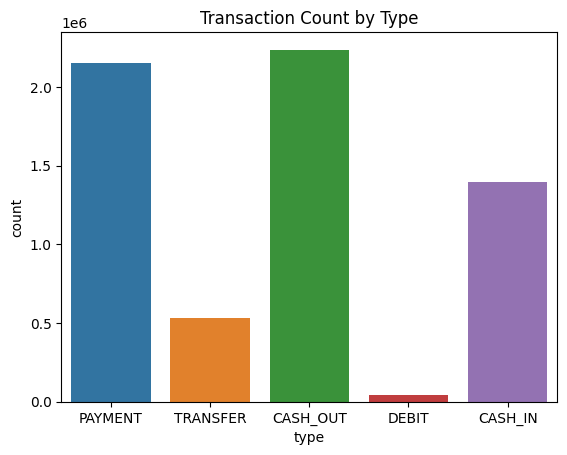

In [14]:
sns.countplot(data=df, x='type', hue='type')
plt.title('Transaction Count by Type')

In [18]:
df['isFraud'].value_counts()

,count
isFraud,
Legit Transaction,6354407
Fraud Transaction,8213


Thus, there seems to be 8,213 fraud transactions

In [15]:
df.groupby('type')['isFraud'].value_counts()

type      isFraud          
CASH_IN   Legit Transaction    1399284
CASH_OUT  Legit Transaction    2233384
          Fraud Transaction       4116
DEBIT     Legit Transaction      41432
PAYMENT   Legit Transaction    2151495
TRANSFER  Legit Transaction     528812
          Fraud Transaction       4097
Name: count, dtype: int64

Understandably, fraud transactions are of only 2 types: 4,116 Cash_out & 4,097 Transfer

In [18]:
df.groupby('isFraud')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
Fraud Transaction,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00
Legit Transaction,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64


In [19]:
print('Mode Amount: ', stats.mode(df['amount']))
print('Mean Amount(q2): ', np.mean(df['amount']))

q1=np.quantile(df['amount'], 0.25)
q3=np.quantile(df['amount'], 0.75)
print('q1: ', q1)
print('q3: ', q3)

IQR=q3-q1
print('IQR: ', IQR)

upper_bound=q3+(1.5*IQR)
lower_bound=q1-(1.5*IQR)
print('Lower Bound: ', lower_bound)
print('Upper Bound: ', upper_bound)

print('Skewed Data1 (less than Lower Bound): ', len(df[df['amount']<lower_bound]))
print('Skewed Data2 (more than Upper Bound): ', len(df[df['amount']>upper_bound]))

Mode Amount:  ModeResult(mode=np.float64(10000000.0), count=np.int64(3207))
Mean Amount(q2):  179861.90354913071
q1:  13389.57
q3:  208721.4775
IQR:  195331.9075
Lower Bound:  -279608.29125
Upper Bound:  501719.33875
Skewed Data1 (less than Lower Bound):  0
Skewed Data2 (more than Upper Bound):  338078


In [20]:
#Encoding the string values in Type column to integer mapping
le=LabelEncoder()
df['type']=le.fit_transform(df['type'])

#Extracting the map inside of Label Encoder
mapping=dict(zip(le.classes_, range(len(le.classes_))))
print(mapping)

{'CASH_IN': 0, 'CASH_OUT': 1, 'DEBIT': 2, 'PAYMENT': 3, 'TRANSFER': 4}


<Axes: >

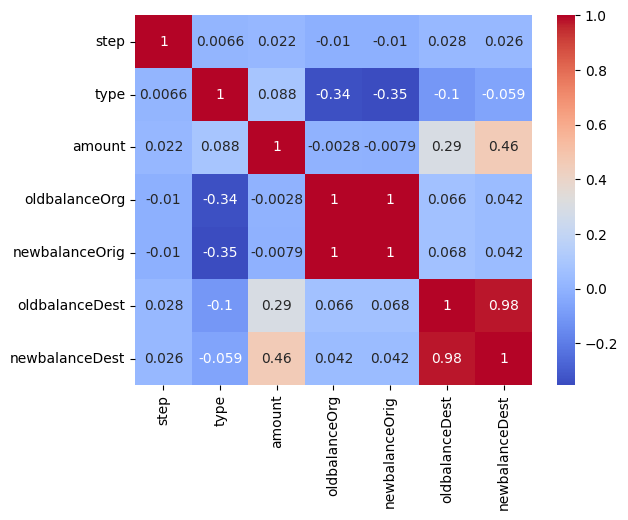

In [21]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [22]:
#Feature Scaling

#Defining independent variable
x=df.drop('isFraud', axis=1)

#defining target variable
y=df['isFraud']

#Standardizing the features of dataframe variables having different scales to remove mean and scaling to unit variance
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
x_scaled

array([[-1.70304158,  0.95239932, -0.28155992, ..., -0.2376217 ,
        -0.3238139 , -0.33341141],
       [-1.70304158,  0.95239932, -0.29476726, ..., -0.2858123 ,
        -0.3238139 , -0.33341141],
       [-1.70304158,  1.69307616, -0.2975548 , ..., -0.29244171,
        -0.3238139 , -0.33341141],
       ...,
       [ 3.51012348, -0.52895436, 10.1539526 , ..., -0.29244171,
        -0.30366526,  1.403027  ],
       [ 3.51012348,  1.69307616,  1.1097649 , ..., -0.29244171,
        -0.3238139 , -0.33341141],
       [ 3.51012348, -0.52895436,  1.1097649 , ..., -0.29244171,
         1.59138312,  1.6698123 ]])

In [24]:
#Splitting the dataset into Train & Test subsets
x_train, x_test, y_train, y_test=train_test_split(x_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(x_train.shape,
      x_test.shape,
      y_train.shape,
      y_test.shape)

(5090096, 7) (1272524, 7) (5090096,) (1272524,)


In [25]:
#MODEL 1: Decision Tree
dtc=DecisionTreeClassifier()
dtc.fit(x_train, y_train)

y_test_pred_dtc=dtc.predict(x_test)
print('Decision Tree Classifier Test Accuracy:', accuracy_score(y_test, y_test_pred_dtc))

y_train_pred_dtc=dtc.predict(x_train)
print('Decision Tree Classifier Train Accuracy:', accuracy_score(y_train, y_train_pred_dtc))

print('Decision Tree Classifier Confusion Matrix:\n', pd.crosstab(y_test, y_test_pred_dtc))
print('Classification Report:\n', classification_report(y_test, y_test_pred_dtc))

Decision Tree Classifier Test Accuracy: 0.999725741911351
Decision Tree Classifier Train Accuracy: 1.0
Decision Tree Classifier Confusion Matrix:
 col_0              Fraud Transaction  Legit Transaction
isFraud                                                
Fraud Transaction               1459                184
Legit Transaction                165            1270716
Classification Report:
                    precision    recall  f1-score   support

Fraud Transaction       0.90      0.89      0.89      1643
Legit Transaction       1.00      1.00      1.00   1270881

         accuracy                           1.00   1272524
        macro avg       0.95      0.94      0.95   1272524
     weighted avg       1.00      1.00      1.00   1272524



In [30]:
#MODEL 2: Extra Tree Classifier
etc=ExtraTreesClassifier()
etc.fit(x_train, y_train)

y_test_pred_etc=etc.predict(x_test)
print('Extra Trees Classifier Test Accuracy:', accuracy_score(y_test, y_test_pred_etc))

y_train_pred_etc=etc.predict(x_train)
print('Extra Trees Classifier Train Accuracy:', accuracy_score(y_train, y_train_pred_etc))

print('Extra Trees Classifier Confusion Matrix\n:', pd.crosstab(y_test, y_test_pred_etc))

print(classification_report(y_test, y_test_pred_etc))

Extra Trees Classifier Test Accuracy: 0.9997021667174844
Extra Trees Classifier Train Accuracy: 1.0
Extra Trees Classifier Confusion Matrix
: col_0              Fraud Transaction  Legit Transaction
isFraud                                                
Fraud Transaction               1279                364
Legit Transaction                 15            1270866
                   precision    recall  f1-score   support

Fraud Transaction       0.99      0.78      0.87      1643
Legit Transaction       1.00      1.00      1.00   1270881

         accuracy                           1.00   1272524
        macro avg       0.99      0.89      0.94   1272524
     weighted avg       1.00      1.00      1.00   1272524



In [31]:
#MODEL 3: Random Forest Classifier
rfc=RandomForestClassifier()
rfc.fit(x_train, y_train)

y_test_pred_rfc=rfc.predict(x_test)
print('Random Forest Classifier Test Accuracy:', accuracy_score(y_test, y_test_pred_rfc))

y_train_pred_rfc=rfc.predict(x_train)
print('Random Forest Classifier Train Accuracy:', accuracy_score(y_train, y_train_pred_rfc))

print('Random Forest Classifier Confusion Matrix:\n', pd.crosstab(y_test, y_test_pred_rfc))

print(classification_report(y_test, y_test_pred_rfc))

Random Forest Classifier Test Accuracy: 0.9997037383970754
Random Forest Classifier Train Accuracy: 0.9999998035400511
Random Forest Classifier Confusion Matrix:
 col_0              Fraud Transaction  Legit Transaction
isFraud                                                
Fraud Transaction               1302                341
Legit Transaction                 36            1270845
                   precision    recall  f1-score   support

Fraud Transaction       0.97      0.79      0.87      1643
Legit Transaction       1.00      1.00      1.00   1270881

         accuracy                           1.00   1272524
        macro avg       0.99      0.90      0.94   1272524
     weighted avg       1.00      1.00      1.00   1272524



Because of imbalanced data class (very loow number of fraud transactions against very high number of legit transactions), accuracy is high for all the models. Of all the 4 Classification ML Models used above, Decision Tree Classifier turns out to be the most accurate predictor for the input dataset. Since in bank transactions, missing any Fraud transaction and clearing it as Legit is the biggest business risk, keeping the ratio of False Negatives (Recall value) should be our main focus.
Decision Tree is a clear winner with the highest recall & F-1 Score.

In [26]:
pickle.dump(dtc, open("dtc.pkl", "wb"))

In [27]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 129.3 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.1
    Uninstalling cachetools-7.0.1:
      Successfully uninstalled cachetools-7.0.1


In [28]:
from pyngrok import ngrok
ngrok.set_auth_token('3A1HIiYofOoJDSEboIq4DbcwUOl_6PioJzZw4Df6DewCa5dSi')

In [33]:
import streamlit as st
import pickle
import numpy as np
from pyngrok import ngrok

# Define the Streamlit app content as a string
streamlit_app_code = '''
import streamlit as st
import pickle
import numpy as np
from sklearn.preprocessing import StandardScaler

st.set_page_config(page_title="Online Payments Fraud Detection", layout="centered")

@st.cache_resource
def load_model_and_scaler():
    model = pickle.load(open("dtc.pkl", "rb"))
    scaler = StandardScaler()
    return model, scaler

model, scaler_placeholder = load_model_and_scaler()

st.title("Online Payment Fraud Detection")
st.write("Enter transaction details below")

# ---- Input Fields ----
step = st.number_input("Step (Transaction time step)", min_value=0, value=1)

transaction_type = st.selectbox(
    "Transaction Type",
    ["CASH_OUT", "PAYMENT", "TRANSFER", "DEBIT", "CASH_IN"]
)

amount = st.number_input("Amount", min_value=0.0, value=0.0)
oldbalanceOrg = st.number_input("Old Balance Origin", min_value=0.0, value=0.0)
newbalanceOrig = st.number_input("New Balance Origin", min_value=0.0, value=0.0)
oldbalanceDest = st.number_input("Old Balance Destination", min_value=0.0, value=0.0)
newbalanceDest = st.number_input("New Balance Destination", min_value=0.0, value=0.0)

type_mapping = {
    "CASH_IN": 0,
    "CASH_OUT": 1,
    "DEBIT": 2,
    "PAYMENT": 3,
    "TRANSFER": 4
}

encoded_type = type_mapping[transaction_type]

if st.button("Predict Fraud"):
    input_data = np.array([[step, encoded_type, amount,
                            oldbalanceOrg, newbalanceOrig,
                            oldbalanceDest, newbalanceDest]])

    prediction = model.predict(input_data)[0]

    if prediction == 'Fraud Transaction': # Compare with string output
        st.error("⚠️ Fraudulent Transaction Detected!")
    else:
        st.success("✅ Legitimate Transaction")
'''

# Write the Streamlit app code to app.py
with open("app.py", "w") as f:
    f.write(streamlit_app_code)

# Set your ngrok authentication token
ngrok.set_auth_token("3A1HIiYofOoJDSEboIq4DbcwUOl_6PioJzZw4Df6DewCa5dSi")

# Kill any existing ngrok tunnels
ngrok.kill()

# Start Streamlit app in the background
print("Starting Streamlit app in the background...")
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > /dev/null 2>&1 &

# Give Streamlit some time to start up
import time
time.sleep(5)

# Connect ngrok to the Streamlit app port
print("Connecting ngrok...")
public_url = ngrok.connect(8501)
print("Public URL:", public_url)

Starting Streamlit app in the background...
Connecting ngrok...
Public URL: NgrokTunnel: "https://nonmodal-carmel-polysomic.ngrok-free.dev" -> "http://localhost:8501"
